In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/US Superstore data.xls")
df = df.set_index("Row ID")




---


* Which state's sales are more?


---



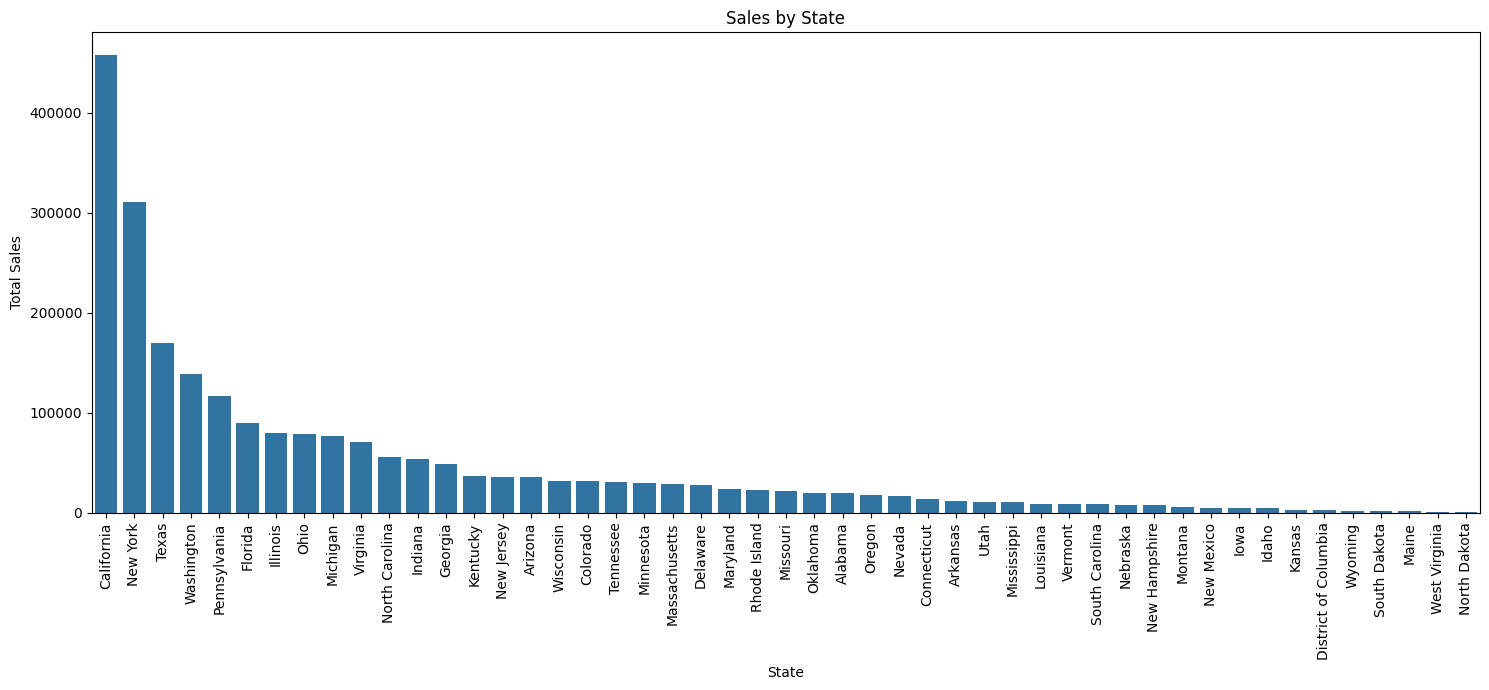

Top 5 States by Sales:
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64


In [ ]:

state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(15,7))
sns.barplot(x=state_sales.index, y=state_sales.values)
plt.xticks(rotation=90)
plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

print("Top 5 States by Sales:")
print(state_sales.head())



---


* What is the difference between New York and California in terms of sales and profit?
* (Compare the total sales and profit between New York and California.)


---



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

Sales_NY = df[df["State"] == "New York"]["Sales"].sum()
Profit_NY = df[df["State"] == "New York"]["Profit"].sum()

Sales_CA = df[df["State"] == "California"]["Sales"].sum()
Profit_CA = df[df["State"] == "California"]["Profit"].sum()

print("\nComparison between New York and California:")
print(f"New York Total Sales: {Sales_NY:.2f}")
print(f"California Total Sales: {Sales_CA:.2f}")
print(f"New York Total Profit: {Profit_NY:.2f}")
print(f"California Total Profit: {Profit_CA:.2f}")

# You already calculated the differences, you can print them again for clarity
print("\nDifference in Sales (New York - California):", diff_sales)
print("Difference in Profit (New York - California):", diff_profit)

Difference in Sales (New York - California): -146811.36050000007
Difference in Profit (New York - California): -2342.838499999998




---


Who is an outstanding customer in New York?


---



In [27]:
# Outstanding Customer in New York by Sales
NY_data = df[df["State"] == "New York"]
customer_sales = NY_data.groupby("Customer Name")["Sales"].sum()
print("Customer by Sales:", customer_sales.idxmax())
print("Total Sales:", customer_sales.max())

# Outstanding Customer in New York by Profit
NY_data = df[df["State"] == "New York"]
customer_profit = NY_data.groupby("Customer Name")["Profit"].sum()
print("Customer by Profit:", customer_profit.idxmax())
print("Total Profit:", customer_profit.max())



Customer by Sales: Tom Ashbrook
Total Sales: 13723.498000000001
Customer by Profit: Tom Ashbrook
Total Profit: 4599.207299999999




---


* Are there any differences among states in profitability?

---



<ipython-input-39-7600074d3af4>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_profitability.index, y=state_profitability.values, palette=colors)


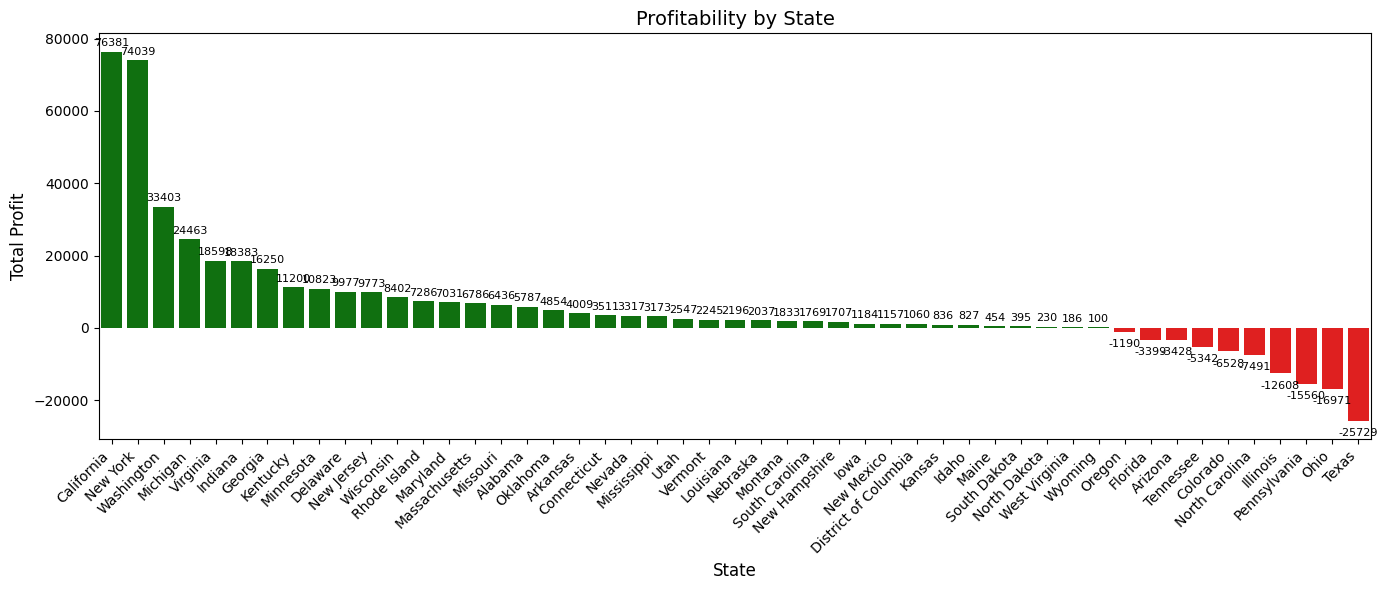

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

state_profitability = df.groupby("State")["Profit"].sum().sort_values(ascending=False)

colors = ['green' if val >= 0 else 'red' for val in state_profitability.values]

plt.figure(figsize=(14, 6))

sns.barplot(x=state_profitability.index, y=state_profitability.values, palette=colors)


plt.title("Profitability by State", fontsize=14)
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Profit", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)


for i, val in enumerate(state_profitability.values):
    plt.text(i, val + (1000 if val >= 0 else -2000), f"{val:.0f}", ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

**There are clear differences in profitability among the states.**
* Some states, such as California and New York, show significantly higher total profits, while others, like Texas or Illinois, may even show negative profits.
* This suggests that regional performance varies and may require different business strategies per state.



---

*The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies.*


---



* Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)


---



In [62]:
import pandas as pd

# Step 1: Group by customer and calculate total profit per customer, sorted descending
customer_profit = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)

# Step 2: Calculate total profit and cumulative profit percentage
total_profit = customer_profit.sum()
cumulative_profit_percent = customer_profit.cumsum() / total_profit * 100

# Step 3: Calculate cumulative percentage of customers
percent_customers = [i / len(customer_profit) * 100 for i in range(1, len(customer_profit) + 1)]

# Step 4: Combine into a DataFrame for Pareto analysis
pareto_df = pd.DataFrame({
    "Customer": customer_profit.index,
    "Profit": customer_profit.values,
    "Cumulative Profit %": cumulative_profit_percent.values,
    "Cumulative Customers %": percent_customers
})

# Step 5: Print out each customer's contribution to total profit and customer base
for cust, profit_pct, cust_pct in zip(customer_profit.index, cumulative_profit_percent, percent_customers):
    continue

# Step 6: Filter top customers that contribute to the first 80% of total profit
top_customers = pareto_df[pareto_df["Cumulative Profit %"] <= 80]

# Step 7: Output result of Pareto principle application
print(f"\nNumber of customers contributing to 80% of profit: {len(top_customers)}")
print(f"Percentage of total customers: {len(top_customers) / len(pareto_df) * 100:.2f}%")


Number of customers contributing to 80% of profit: 152
Percentage of total customers: 19.17%



---

* What are the Top 20 cities by Sales ?
* What about the Top 20 cities by Profit ?
* Are there any difference among cities in profitability ?
* (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)

---

In [ ]:
#Calculate total sales by city and get top 20 cities
top_cities_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(20)
print("Top 20 Cities by Sales:")
print(top_cities_sales)

#Calculate total profit by city and get top 20 cities
top_cities_profit = df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(20)
print("\nTop 20 Cities by Profit:")
print(top_cities_profit)

#Get total profit for all cities (not just top 20)
cityes_profitability = df.groupby("City")["Profit"].sum().sort_values(ascending=False)
print("\nCity Profitability:")
print(cityes_profitability)

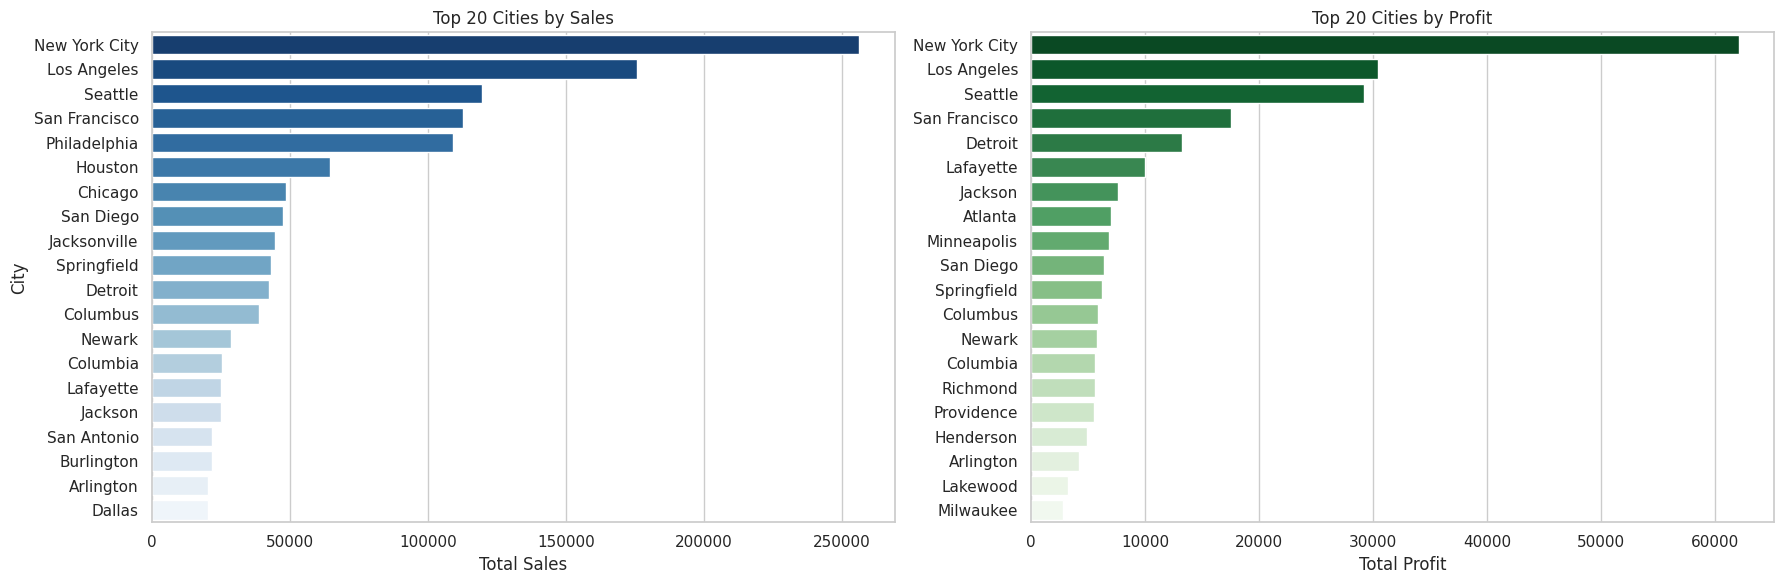

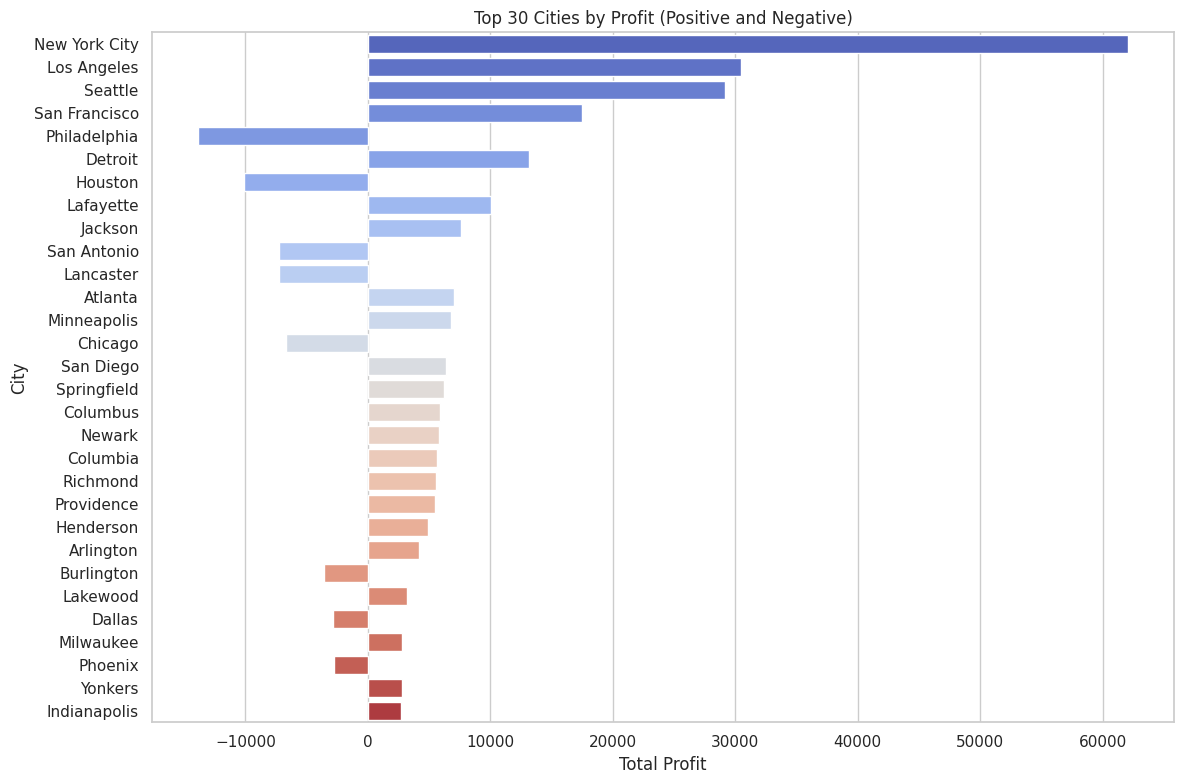

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#Top 20 Cities by Sales
sns.barplot(ax=axes[0], x=top_cities_sales.values, y=top_cities_sales.index,hue=top_cities_sales.index, palette="Blues_r", legend = False)
axes[0].set_title("Top 20 Cities by Sales")
axes[0].set_xlabel("Total Sales")
axes[0].set_ylabel("City")

# Top 20 Cities by Profit
sns.barplot(ax=axes[1], x=top_cities_profit.values, y=top_cities_profit.index,  hue=top_cities_profit.index, palette="Greens_r", legend=False)
axes[1].set_title("Top 20 Cities by Profit")
axes[1].set_xlabel("Total Profit")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# 30 cities by absolute profit (positive + negative)
top30_profit = cityes_profitability.abs().sort_values(ascending=False).head(30)
top30_profit_values = cityes_profitability.loc[top30_profit.index]

plt.figure(figsize=(12, 8))
sns.barplot(x=top30_profit_values.values, y=top30_profit_values.index,hue=top30_profit_values.index, palette="coolwarm", legend = False)

plt.title("Top 30 Cities by Profit (Positive and Negative)")
plt.xlabel("Total Profit")
plt.ylabel("City")
plt.tight_layout()
plt.show()



---


There is a clear disparity in profitability among the top 30 cities.

Cities like New York City, Los Angeles, and Seattle generate the highest profits, while cities such as Indianapolis, Yonkers, and Phoenix show consistent losses.

This indicates that a small group of cities contributes the majority of the profit, while others may require further analysis or strategic improvement.


---




What are the Top 20 customers by Sales?

---




---



In [ ]:
top_customers_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(20)
print("Top 20 Customers by Sales:")
print(top_customers_sales)


---
* Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
---

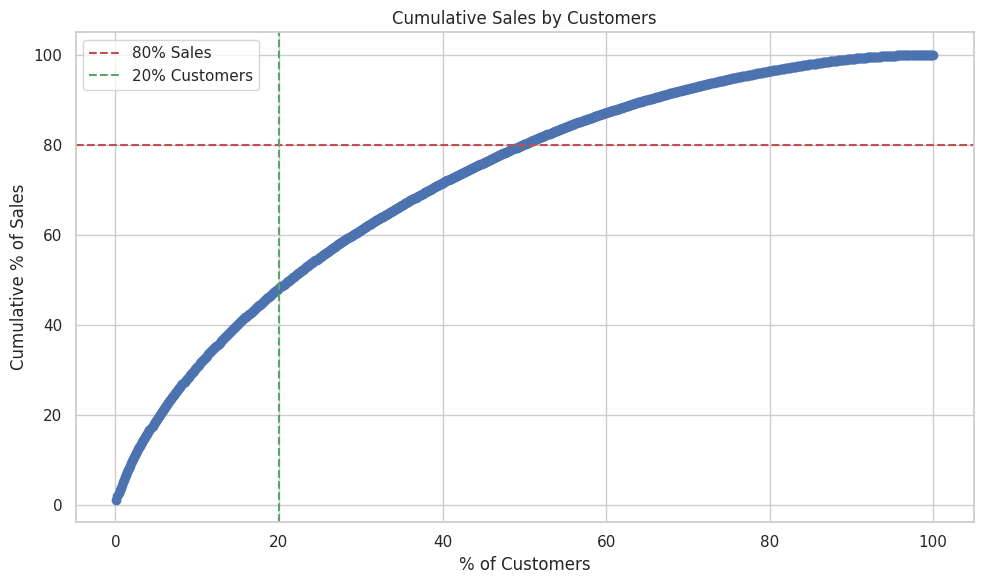

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# groupby sale by clients
customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

# calculate cumulative_sales
cumulative_sales = customer_sales.cumsum() / customer_sales.sum() * 100
cumulative_customers = [i / len(customer_sales) * 100 for i in range(1, len(customer_sales)+1)]

# create a graph
plt.figure(figsize=(10,6))
plt.plot(cumulative_customers, cumulative_sales, marker='o')
plt.axhline(80, color='r', linestyle='--', label='80% Sales')
plt.axvline(20, color='g', linestyle='--', label='20% Customers')
plt.title('Cumulative Sales by Customers')
plt.xlabel('% of Customers')
plt.ylabel('Cumulative % of Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Conclusion:**

* If you see that 20% of customers provide ~80% of sales, then the Pareto principle applies.
* If not, then the distribution of sales is more even.

---

Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

---

Based on the analysis, marketing strategies should prioritize **high-profit states and cities** such as New York City, Los Angeles, and Seattle, which generate the most revenue.

At the same time, **low-profit or negative-profit cities** like Indianapolis, Yonkers, and Phoenix should be reviewed for operational inefficiencies or revised marketing tactics.

Focusing on top-performing locations while optimizing underperforming ones will improve overall profitability and resource allocation.